In [2]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import find_peaks
import matplotlib.pyplot as plt


In [3]:
subject = "sub-racsleep04b"
subject_dir = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/eeg/"
behavior_mat = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/behav/{subject.replace('sub-', '')}_run01_buttonpresses_clean.mat"


In [4]:
metrics_path = os.path.join(subject_dir, "metrics.mat")
metrics = sio.loadmat(metrics_path, squeeze_me=True, struct_as_record=False)
eeg_struct = metrics["eeg"]


In [6]:

eeg_t = np.squeeze(eeg_struct.t_clean)
ratio = np.squeeze(eeg_struct.alpha_delta_clean)
print(f"EEG loaded: {len(eeg_t)} samples, from {eeg_t[0]:.1f}s to {eeg_t[-1]:.1f}s")


# interpolation for even spaced time vector
dt = np.median(np.diff(eeg_t))       # median sampling interval
even_t = np.arange(eeg_t[0], eeg_t[-1], dt)
ratio_interp = np.interp(even_t, eeg_t, ratio)


EEG loaded: 24645 samples, from 9.5s to 5363.1s


In [11]:
# moving average calculated uing convolution
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'same') / w

# about 20 second window for smoothingg
window = int(20 / dt)
ratio_smooth = moving_average(ratio_interp, window)

# z score for smoothed ratio-
ratio_z = (ratio_smooth - np.nanmean(ratio_smooth)) / np.nanstd(ratio_smooth)


In [12]:
# detect arousals 
inv = -ratio_z  # invert to detect sharp downward α/δ deflections
peaks, _ = find_peaks(inv, distance=int(8.0 / dt), prominence=0.8)
eeg_arousals = even_t[peaks]
print(f"Detected {len(eeg_arousals)} EEG-based arousals (after convolution smoothing)")


Detected 46 EEG-based arousals (after convolution smoothing)


In [13]:
# button pressing 
mat = sio.loadmat(behavior_mat)
press_times = mat['buttonpresses_clean'].flatten()

threshold = 20  
intervals = np.diff(press_times)
arousal_indices = np.where(intervals >= threshold)[0] + 1
arousal_times = press_times[arousal_indices]

sustained, transient = [], []
for t in arousal_times:
    following = press_times[(press_times > t) & (press_times <= t + 20)]
    if len(following) >= 5:
        sustained.append(t)
    elif len(following) <= 2:
        transient.append(t)
sustained = np.array(sustained)
transient = np.array(transient)

print(f"Sustained arousals: {len(sustained)}, Transient arousals: {len(transient)}")


Sustained arousals: 10, Transient arousals: 6


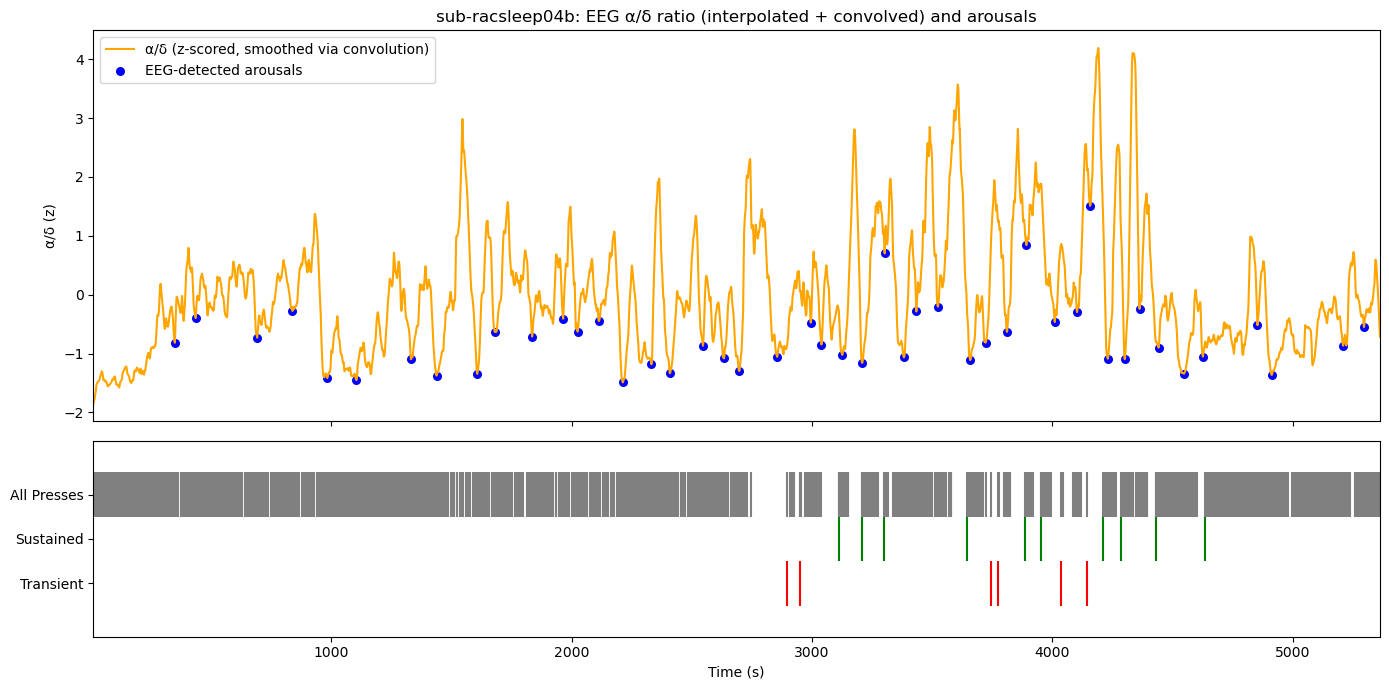

In [14]:
# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios':[2,1]})

# EEG α/δ ratio (z-scored, smoothed)
axs[0].plot(even_t, ratio_z, color='orange', label='α/δ (z-scored, smoothed via convolution)')
axs[0].scatter(eeg_arousals, np.interp(eeg_arousals, even_t, ratio_z),
               color='blue', s=30, label='EEG-detected arousals')
axs[0].set_ylabel("α/δ (z)")
axs[0].legend()
axs[0].set_title(f"{subject}: EEG α/δ ratio (interpolated + convolved) and arousals")

# behavioral button presses
axs[1].eventplot([press_times, sustained, transient],
                 colors=['gray', 'green', 'red'],
                 lineoffsets=[0.6, 0.3, 0.0],
                 linelengths=[0.3, 0.3, 0.3])
axs[1].set_yticks([0, 0.3, 0.6])
axs[1].set_yticklabels(["Transient", "Sustained", "All Presses"])
axs[1].set_xlabel("Time (s)")
axs[1].set_xlim(even_t[0], even_t[-1])

plt.tight_layout()
plt.show()


